In [1]:
%matplotlib inline
suppress_warnings = True
import os                                                     # to set current working directory
import math                                                   # square root operator
import numpy as np                                            # arrays and matrix math
import scipy.stats as st                                      # statistical methods
import pandas as pd                                           # DataFrames
import matplotlib.pyplot as plt                               # for plotting
from matplotlib.ticker import (MultipleLocator,AutoMinorLocator,FuncFormatter) # control of axes ticks
from matplotlib.colors import ListedColormap                  # custom color maps
import seaborn as sns                                         # for matrix scatter plots
from sklearn.tree import DecisionTreeRegressor                # decision tree method
from sklearn.ensemble import GradientBoostingRegressor        # tree-based gradient boosting
from sklearn.tree import _tree                                # for accessing tree information
from sklearn import metrics                                   # measures to check our models
from sklearn.preprocessing import StandardScaler              # standardize the features
from sklearn.tree import export_graphviz                      # graphical visualization of trees
from sklearn.model_selection import (cross_val_score,train_test_split,GridSearchCV,KFold) # model tuning
from sklearn.pipeline import (Pipeline,make_pipeline)         # machine learning modeling pipeline
from sklearn import metrics                                   # measures to check our models
from sklearn.model_selection import cross_val_score           # multi-processor K-fold crossvalidation
from sklearn.model_selection import train_test_split          # train and test split
from IPython.display import display, HTML                     # custom displays
cmap = plt.cm.inferno                                         # default color bar, no bias and friendly for color vision defeciency
plt.rc('axes', axisbelow=True)                                # grid behind plotting elements
if suppress_warnings == True:
    import warnings                                           # suppress any warnings for this demonstration
    warnings.filterwarnings('ignore')
seed = 13                                                     # random number seed for workflow repeatability

In [2]:
def comma_format(x, pos):
    return f'{int(x):,}'

def feature_rank_plot(pred,metric,mmin,mmax,nominal,title,ylabel,mask): # feature ranking plot
    mpred = len(pred); mask_low = nominal-mask*(nominal-mmin); mask_high = nominal+mask*(mmax-nominal); m = len(pred) + 1
    plt.plot(pred,metric,color='black',zorder=20)
    plt.scatter(pred,metric,marker='o',s=10,color='black',zorder=100)
    plt.plot([-0.5,m-1.5],[0.0,0.0],'r--',linewidth = 1.0,zorder=1)
    plt.fill_between(np.arange(0,mpred,1),np.zeros(mpred),metric,where=(metric < nominal),interpolate=True,color='dodgerblue',alpha=0.3)
    plt.fill_between(np.arange(0,mpred,1),np.zeros(mpred),metric,where=(metric > nominal),interpolate=True,color='lightcoral',alpha=0.3)
    plt.fill_between(np.arange(0,mpred,1),np.full(mpred,mask_low),metric,where=(metric < mask_low),interpolate=True,color='blue',alpha=0.8,zorder=10)
    plt.fill_between(np.arange(0,mpred,1),np.full(mpred,mask_high),metric,where=(metric > mask_high),interpolate=True,color='red',alpha=0.8,zorder=10)
    plt.xlabel('Predictor Features'); plt.ylabel(ylabel); plt.title(title)
    plt.ylim(mmin,mmax); plt.xlim([-0.5,m-1.5]); add_grid();
    return

def plot_corr(corr_matrix,title,limits,mask):                 # plots a graphical correlation matrix
    my_colormap = plt.get_cmap('RdBu_r', 256)
    newcolors = my_colormap(np.linspace(0, 1, 256))
    white = np.array([256/256, 256/256, 256/256, 1])
    white_low = int(128 - mask*128); white_high = int(128+mask*128)
    newcolors[white_low:white_high, :] = white                # mask all correlations less than abs(0.8)
    newcmp = ListedColormap(newcolors)
    m = corr_matrix.shape[0]
    im = plt.matshow(corr_matrix,fignum=0,vmin = -1.0*limits, vmax = limits,cmap = newcmp)
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns); ax = plt.gca()
    ax.xaxis.set_label_position('bottom'); ax.xaxis.tick_bottom()
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
    plt.colorbar(im, orientation = 'vertical')
    plt.title(title)
    for i in range(0,m):
        plt.plot([i-0.5,i-0.5],[-0.5,m-0.5],color='black')
        plt.plot([-0.5,m-0.5],[i-0.5,i-0.5],color='black')
    plt.ylim([-0.5,m-0.5]); plt.xlim([-0.5,m-0.5])

def add_grid():
    plt.gca().grid(True, which='major',linewidth = 1.0); plt.gca().grid(True, which='minor',linewidth = 0.2) # add y grids
    plt.gca().tick_params(which='major',length=7); plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator()); plt.gca().yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks

def plot_CDF(data,color,alpha=1.0,lw=1,ls='solid',label='none'):
    cumprob = (np.linspace(1,len(data),len(data)))/(len(data)+1)
    plt.scatter(np.sort(data),cumprob,c=color,alpha=alpha,edgecolor='black',lw=lw,ls=ls,label=label,zorder=10)
    plt.plot(np.sort(data),cumprob,c=color,alpha=alpha,lw=lw,ls=ls,zorder=8)

def visualize_model(model,X1_train,X1_test,X2_train,X2_test,Xmin,Xmax,y_train,y_test,ymin,
                         ymax,title,Xname,yname,Xlabel,ylabel,annotate=True):# plots the data points and the decision tree prediction
    cmap = plt.cm.inferno
    X1plot_step = (Xmax[0] - Xmin[0])/300.0; X2plot_step = -1*(Xmax[1] - Xmin[1])/300.0 # resolution of the model visualization
    XX1, XX2 = np.meshgrid(np.arange(Xmin[0], Xmax[0], X1plot_step), # set up the mesh
                     np.arange(Xmax[1], Xmin[1], X2plot_step))
    y_hat = model.predict(np.c_[XX1.ravel(), XX2.ravel()])    # predict with our trained model over the mesh
    y_hat = y_hat.reshape(XX1.shape)

    plt.imshow(y_hat,interpolation=None, aspect="auto", extent=[Xmin[0],Xmax[0],Xmin[1],Xmax[1]],
        vmin=ymin,vmax=ymax,alpha = 1.0,cmap=cmap,zorder=1)
    sp = plt.scatter(X1_train,X2_train,s=None, c=y_train, marker='o', cmap=cmap,
        norm=None, vmin=ymin, vmax=ymax, alpha=0.6, linewidths=0.3, edgecolors="black", label = 'Train',zorder=10)
    plt.scatter(X1_test,X2_test,s=None, c=y_test, marker='s', cmap=cmap,
        norm=None, vmin=ymin, vmax=ymax, alpha=0.3, linewidths=0.3, edgecolors="black", label = 'Test',zorder=10)
    plt.title(title); plt.xlabel(Xlabel[0]); plt.ylabel(Xlabel[1])
    plt.xlim([Xmin[0],Xmax[0]]); plt.ylim([Xmin[1],Xmax[1]])
    cbar = plt.colorbar(sp, orientation = 'vertical')         # add the color bar
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(comma_format))
    plt.gca().xaxis.set_major_formatter(FuncFormatter(comma_format))
    plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_format))
    cbar.set_label(ylabel, rotation=270, labelpad=20)
    return y_hat

def check_model(model,X,y,ymin,ymax,ylabel,title): # get OOB MSE and cross plot a decision tree
    y_hat = model.predict(X)
    MSE_test = metrics.mean_squared_error(y,y_hat)
    plt.scatter(y,y_hat,s=None, c='darkorange',marker=None,cmap=cmap,norm=None,vmin=None,vmax=None,alpha=0.8,
                linewidths=1.0, edgecolors="black")
    plt.title(title); plt.xlabel('Truth: ' + str(ylabel)); plt.ylabel('Estimated: ' + str(ylabel))
    plt.xlim(ymin,ymax); plt.ylim(ymin,ymax)
    plt.plot([ymin,ymax],[ymin,ymax],color='black'); add_grid()
    plt.annotate('Testing MSE: ' + str(f'{(np.round(MSE_test,2)):,.0f}'),[4200,2500])
    plt.gca().xaxis.set_major_formatter(FuncFormatter(comma_format))
    plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_format))

def display_sidebyside(*args):                                # display DataFrames side-by-side (ChatGPT 4.0 generated Spet, 2024)
    html_str = ''
    for df in args:
        html_str += df.head().to_html()  # Using .head() for the first few rows
    display(HTML(f'<div style="display: flex;">{html_str}</div>'))

In [3]:
add_error = True                                              # add random error to the response feature
std_error = 1000                                               # standard deviation of random error, for demonstration only
idata = 2

if idata == 1:
    df_load = pd.read_csv(r"https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/unconv_MV.csv") # load the data from my github repo
    df_load = df_load.sample(frac=.30, random_state = seed); df_load = df_load.reset_index() # extract 30% random to reduce the number of data

elif idata == 2:
    df_load = pd.read_csv(r"https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/unconv_MV_v5.csv") # load the data
    df_load = df_load.sample(frac=.70, random_state = seed); df_load = df_load.reset_index() # extract 30% random to reduce the number of data
    df_load = df_load.rename(columns={"Prod": "Production"})

yname = 'Production'; Xname = ['Por','Brittle']               # specify the predictor features (x2) and response feature (x1)
Xmin = [5.0,0.0]; Xmax = [25.0,100.0]                         # set minimums and maximums for visualization
ymin = 1500.0; ymax = 7000.0
Xlabel = ['Porosity','Brittleness']; ylabel = 'Production'    # specify the feature labels for plotting
Xunit = ['%','%']; yunit = 'MCFPD'
Xlabelunit = [Xlabel[0] + ' (' + Xunit[0] + ')',Xlabel[1] + ' (' + Xunit[1] + ')']
ylabelunit = ylabel + ' (' + yunit + ')'

if add_error == True:                                         # method to add error
    np.random.seed(seed=seed)                                 # set random number seed
    df_load[yname] = df_load[yname] + np.random.normal(loc = 0.0,scale=std_error,size=len(df_load)) # add noise
    values = df_load._get_numeric_data(); values[values < 0] = 0   # set negative to 0 in a shallow copy ndarray

y = pd.DataFrame(df_load[yname])                              # extract selected features as X and y DataFrames
X = df_load[Xname]
df = pd.concat([X,y],axis=1)                                  # make one DataFrame with both X and y (remove all other features)

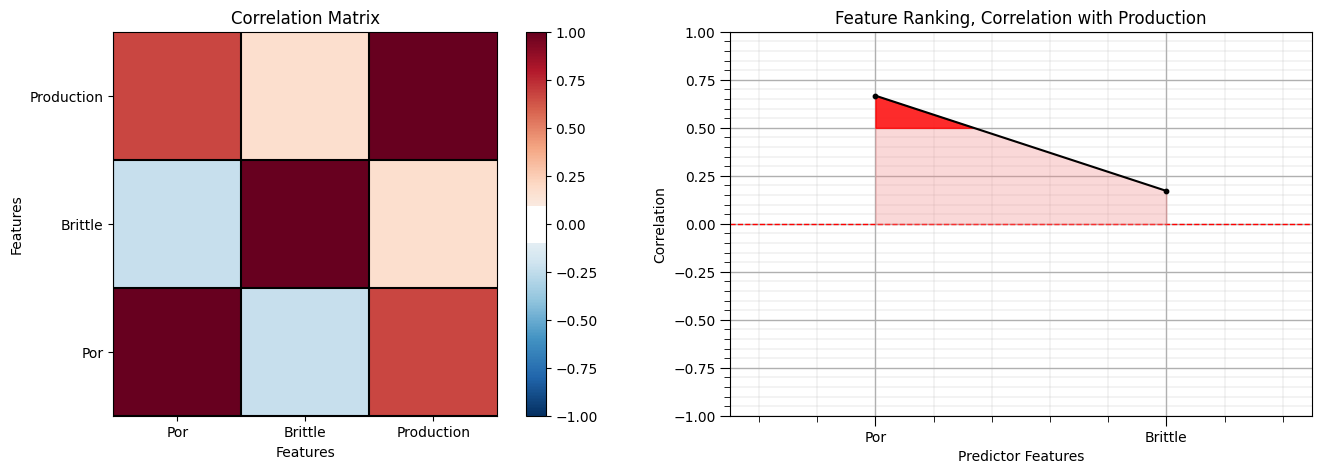

In [4]:
corr_matrix = df.corr()
correlation = corr_matrix.iloc[:,-1].values[:-1]

plt.subplot(121)
plot_corr(corr_matrix,'Correlation Matrix',1.0,0.1)           # using our correlation matrix visualization function
plt.xlabel('Features'); plt.ylabel('Features')

plt.subplot(122)
feature_rank_plot(Xname,correlation,-1.0,1.0,0.0,'Feature Ranking, Correlation with ' + yname,'Correlation',0.5)

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=0.8, wspace=0.2, hspace=0.3); plt.show()

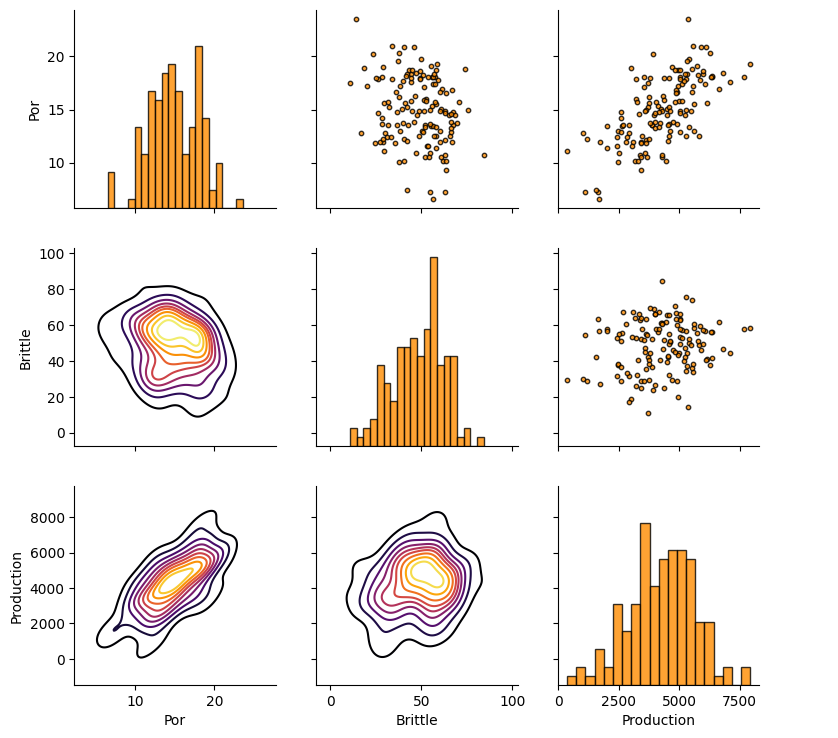

In [5]:
pairgrid = sns.PairGrid(df,vars=Xname+[yname])                # matrix scatter plots
pairgrid = pairgrid.map_upper(plt.scatter, color = 'darkorange', edgecolor = 'black', alpha = 0.8, s = 10)
pairgrid = pairgrid.map_diag(plt.hist, bins = 20, color = 'darkorange',alpha = 0.8, edgecolor = 'k')# Map a density plot to the lower triangle
pairgrid = pairgrid.map_lower(sns.kdeplot, cmap = plt.cm.inferno,
                              alpha = 1.0, n_levels = 10)
pairgrid.add_legend()
plt.subplots_adjust(left=0.0, bottom=0.0, right=0.9, top=0.9, wspace=0.2, hspace=0.2); plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=73073) # train and test split
df_train = pd.concat([X_train,y_train],axis=1)                # make one train DataFrame with both X and y (remove all other features)
df_test = pd.concat([X_test,y_test],axis=1)                   # make one testin DataFrame with both X and y (remove all other features)

In [7]:
print('       Training DataFrame          Testing DataFrame')
display_sidebyside(df_train,df_test)                          # custom function for side-by-side DataFrame display

       Training DataFrame          Testing DataFrame


,Por,Brittle,Production
86,12.83,29.87,995.700671
35,17.39,56.43,6060.760806
75,12.23,40.67,3744.177137
36,13.72,40.24,4203.470533
126,12.83,17.20,2917.165695
,Por,Brittle,Production
5,15.55,58.25,5619.930037
46,20.21,23.78,3897.440411
96,15.07,39.39,4504.608029
45,12.10,63.24,3613.953926


In [8]:
print('            Training DataFrame                      Testing DataFrame')    # custom function for side-by-side summary statistics
display_sidebyside(df_train.describe().loc[['count', 'mean', 'std', 'min', 'max']],df_test.describe().loc[['count', 'mean', 'std', 'min', 'max']])

            Training DataFrame                      Testing DataFrame


,Por,Brittle,Production
count,105.000000,105.000000,105.000000
mean,14.859238,48.861143,4192.479746
std,3.057228,14.432050,1347.391355
min,7.220000,10.940000,357.449794
max,23.550000,84.330000,7934.478879
,Por,Brittle,Production
count,35.000000,35.000000,35.000000
mean,15.011714,46.798286,4431.830496
std,3.574467,13.380910,1487.184992
min,6.550000,20.120000,1572.738774


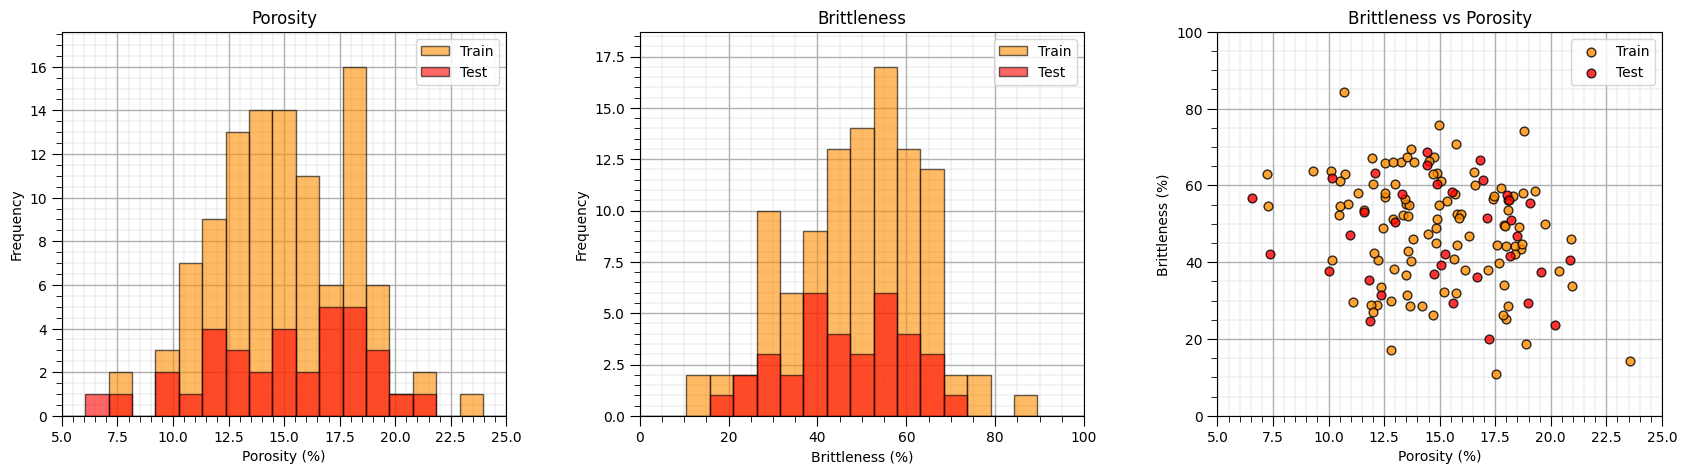

In [9]:
nbins = 20                                                    # number of histogram bins

plt.subplot(131)                                              # predictor feature #1 histogram
freq1,_,_ = plt.hist(x=df_train[Xname[0]],weights=None,bins=np.linspace(Xmin[0],Xmax[0],nbins),alpha = 0.6,
                     edgecolor='black',color='darkorange',density=False,label='Train')
freq2,_,_ = plt.hist(x=df_test[Xname[0]],weights=None,bins=np.linspace(Xmin[0],Xmax[0],nbins),alpha = 0.6,
                     edgecolor='black',color='red',density=False,label='Test')
max_freq = max(freq1.max()*1.10,freq2.max()*1.10)
plt.xlabel(Xlabelunit[0]); plt.ylabel('Frequency'); plt.ylim([0.0,max_freq]); plt.title(Xlabel[0]); add_grid()
plt.xlim([Xmin[0],Xmax[0]]); plt.legend(loc='upper right')

plt.subplot(132)                                              # predictor feature #2 histogram
freq1,_,_ = plt.hist(x=df_train[Xname[1]],weights=None,bins=np.linspace(Xmin[1],Xmax[1],nbins),alpha = 0.6,
                     edgecolor='black',color='darkorange',density=False,label='Train')
freq2,_,_ = plt.hist(x=df_test[Xname[1]],weights=None,bins=np.linspace(Xmin[1],Xmax[1],nbins),alpha = 0.6,
                     edgecolor='black',color='red',density=False,label='Test')
max_freq = max(freq1.max()*1.10,freq2.max()*1.10)
plt.xlabel(Xlabelunit[1]); plt.ylabel('Frequency'); plt.ylim([0.0,max_freq]); plt.title(Xlabel[1]); add_grid()
plt.xlim([Xmin[1],Xmax[1]]); plt.legend(loc='upper right')

plt.subplot(133)                                              # predictor features #1 and #2 scatter plot
plt.scatter(df_train[Xname[0]],df_train[Xname[1]],s=40,marker='o',color = 'darkorange',alpha = 0.8,edgecolor = 'black',zorder=10,label='Train')
plt.scatter(df_test[Xname[0]],df_test[Xname[1]],s=40,marker='o',color = 'red',alpha = 0.8,edgecolor = 'black',zorder=10,label='Test')
plt.title(Xlabel[1] + ' vs ' +  Xlabel[0])
plt.xlabel(Xlabelunit[0]); plt.ylabel(Xlabelunit[1])
plt.legend(); add_grid(); plt.xlim([Xmin[0],Xmax[0]]); plt.ylim([Xmin[1],Xmax[1]])

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.5, top=0.8, wspace=0.3, hspace=0.2)
#plt.savefig('Test.pdf', dpi=600, bbox_inches = 'tight',format='pdf')
plt.show()

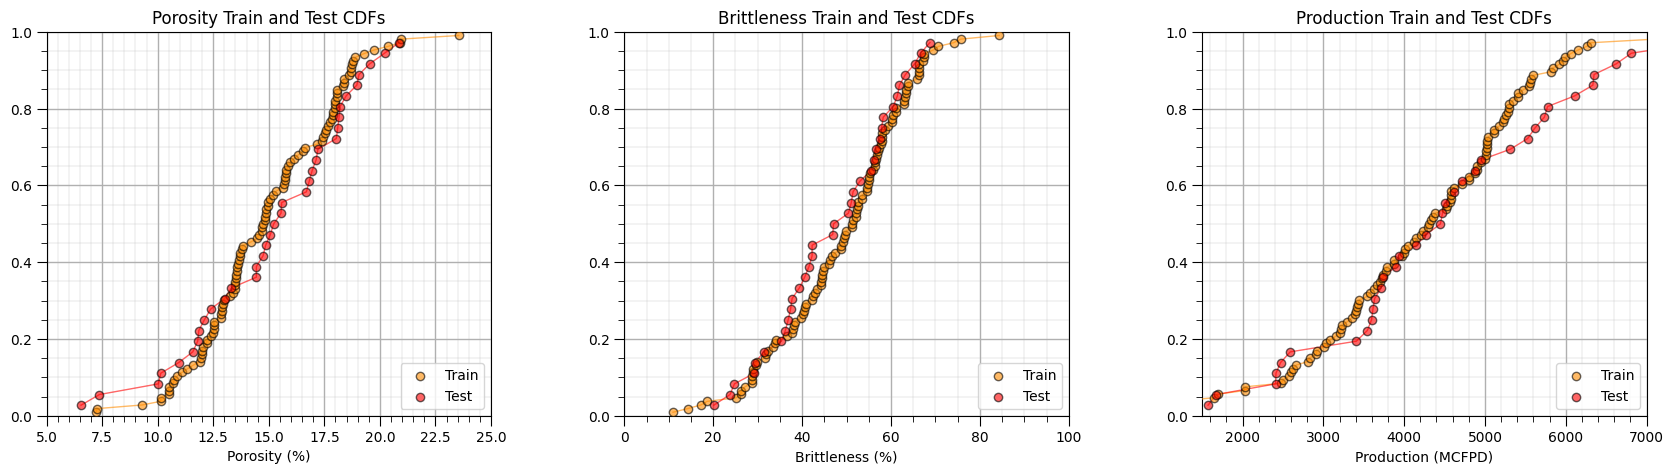

In [10]:
plt.subplot(131)                                              # predictor feature #1 CDF
plot_CDF(X_train[Xname[0]],'darkorange',alpha=0.6,lw=1,ls='solid',label='Train')
plot_CDF(X_test[Xname[0]],'red',alpha=0.6,lw=1,ls='solid',label='Test')
plt.xlabel(Xlabelunit[0]); plt.xlim(Xmin[0],Xmax[0]); plt.ylim([0,1]); add_grid(); plt.legend(loc='lower right')
plt.title(Xlabel[0] + ' Train and Test CDFs')

plt.subplot(132)                                              # predictor feature #2 CDF
plot_CDF(X_train[Xname[1]],'darkorange',alpha=0.6,lw=1,ls='solid',label='Train')
plot_CDF(X_test[Xname[1]],'red',alpha=0.6,lw=1,ls='solid',label='Test')
plt.xlabel(Xlabelunit[1]); plt.xlim(Xmin[1],Xmax[1]); plt.ylim([0,1]); add_grid(); plt.legend(loc='lower right')
plt.title(Xlabel[1] + ' Train and Test CDFs')

plt.subplot(133)                                              # response feature CDF
plot_CDF(y_train[yname],'darkorange',alpha=0.6,lw=1,ls='solid',label='Train')
plot_CDF(y_test[yname],'red',alpha=0.6,lw=1,ls='solid',label='Test')
plt.xlabel(ylabelunit); plt.xlim(ymin,ymax); plt.ylim([0,1]); add_grid(); plt.legend(loc='lower right')
plt.title(ylabel + ' Train and Test CDFs')

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.5, top=0.8, wspace=0.3, hspace=0.2)
#plt.savefig('Test.pdf', dpi=600, bbox_inches = 'tight',format='pdf')
plt.show()

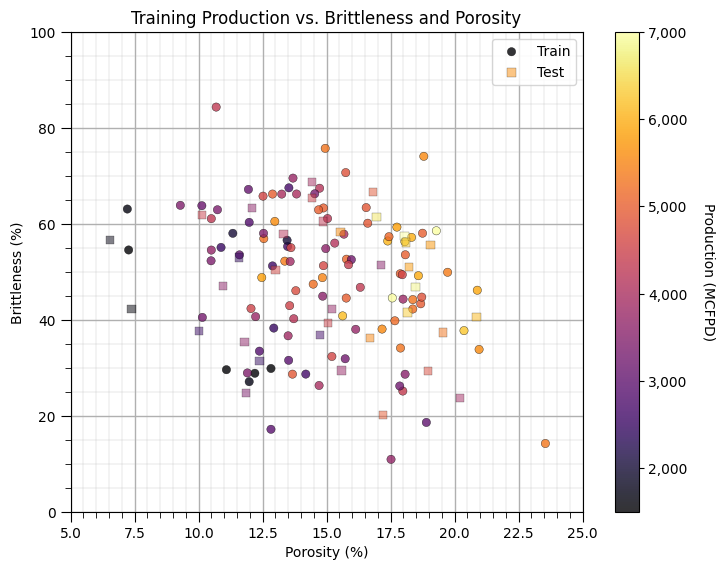

In [11]:
plt.subplot(111)                                              # visualize the train and test data in predictor feature space
im = plt.scatter(X_train[Xname[0]],X_train[Xname[1]],s=None, c=y_train[yname], marker='o', cmap=cmap,
    norm=None, vmin=ymin, vmax=ymax, alpha=0.8, linewidths=0.3, edgecolors="black", label = 'Train')
plt.scatter(X_test[Xname[0]],X_test[Xname[1]],s=None, c=y_test[yname], marker='s', cmap=cmap,
    norm=None, vmin=ymin, vmax=ymax, alpha=0.5, linewidths=0.3, edgecolors="black", label = 'Test')
plt.title('Training ' + ylabel + ' vs. ' + Xlabel[1] + ' and ' + Xlabel[0]);
plt.xlabel(Xlabel[0] + ' (' + Xunit[0] + ')'); plt.ylabel(Xlabel[1] + ' (' + Xunit[1] + ')')
plt.xlim(Xmin[0],Xmax[0]); plt.ylim(Xmin[1],Xmax[1]); plt.legend(loc = 'upper right'); add_grid()
cbar = plt.colorbar(im, orientation = 'vertical')
cbar.set_label(ylabel + ' (' + yunit + ')', rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(comma_format))

plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.2, hspace=0.2); plt.show()

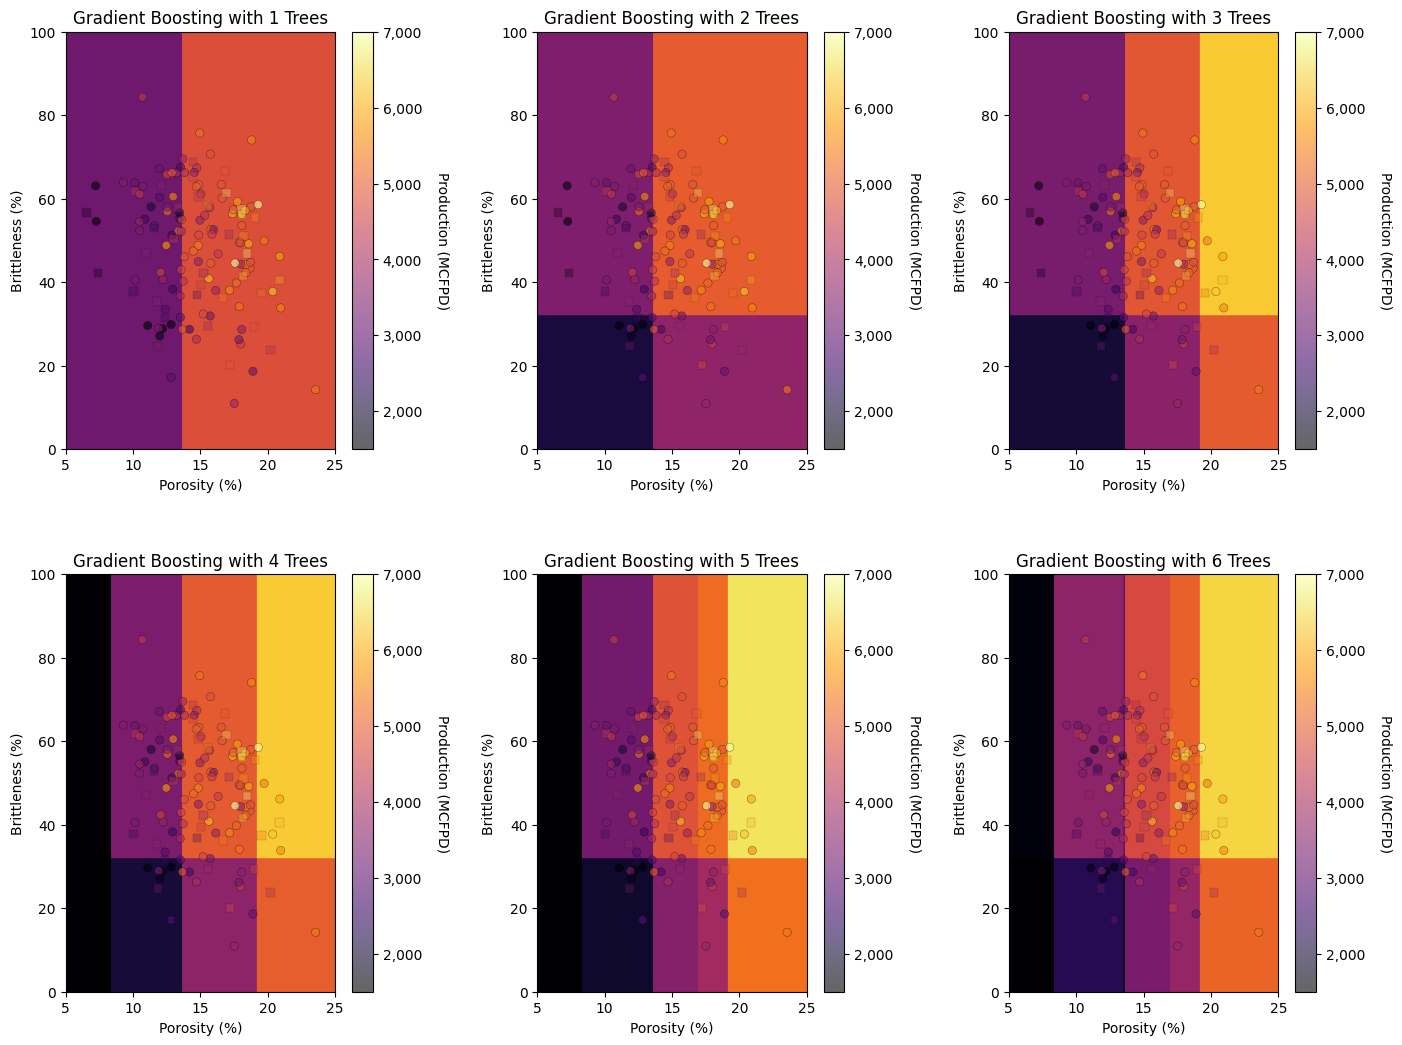

In [12]:
params = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 1,
    'learning_rate': 1.0,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

num_trees = np.linspace(1,6,6)                              # build a list of numbers of trees
boosting_models = []; score = []; pred = []                 # arrays for storage of models and model summaries

index = 1
for num_tree in num_trees:                                  # loop over number of trees
    boosting_models.append(GradientBoostingRegressor(n_estimators=int(num_tree),**params))
    boosting_models[index-1].fit(X = X_train, y = y_train)
    score.append(boosting_models[index-1].score(X = X_test, y = y_test))
    plt.subplot(2,3,index)
    pred.append(visualize_model(boosting_models[index-1],X_train[Xname[0]],X_test[Xname[0]],X_train[Xname[1]],X_test[Xname[1]],Xmin,Xmax,
        y_train[yname],y_test[yname],ymin,ymax,'Gradient Boosting with ' + str(int(num_tree)) + ' Trees',Xname,yname,Xlabelunit,ylabelunit))
    index = index + 1

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=2.0, wspace=0.4, hspace=0.3); plt.show()

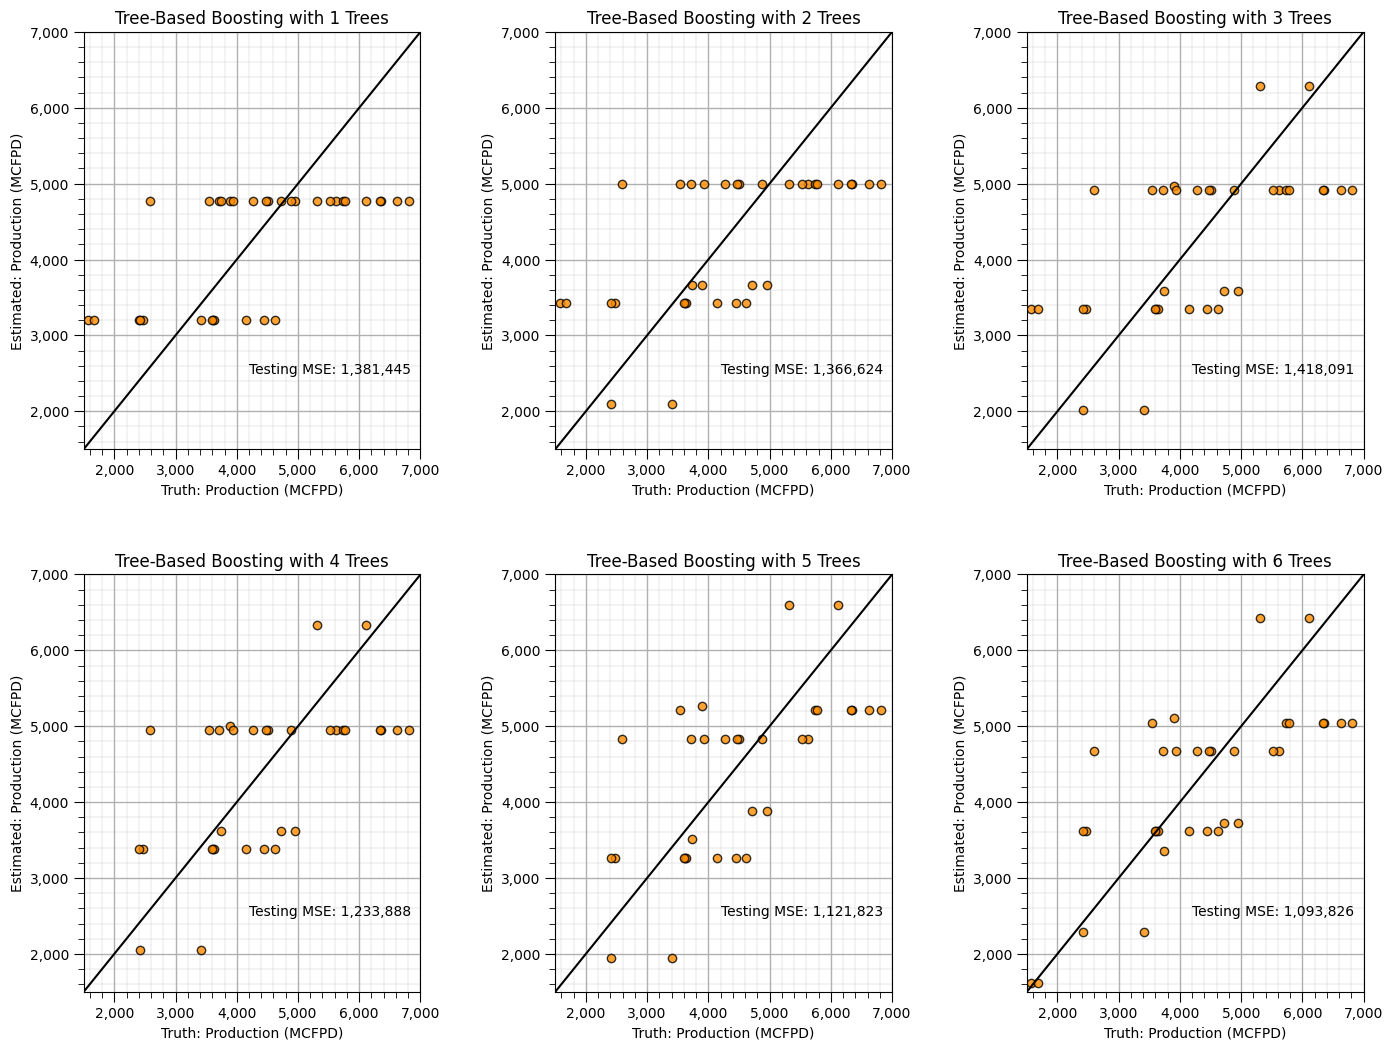

In [13]:
index = 1
for num_tree in num_trees:                                  # check over number of trees
    plt.subplot(2,3,index)
    check_model(boosting_models[index-1],X_test,y_test,ymin,ymax,ylabelunit,'Tree-Based Boosting with ' + str(int(num_tree)) + ' Trees')
    index = index + 1
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=2.0, wspace=0.4, hspace=0.3)

In [ ]:
params = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 1,                                         # maximum depth per tree
    'learning_rate': 1,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

num_trees = [5,10,20,100,500,5000]                          # build a list of numbers of trees
boosting_models = []; score = []; pred = []                 # arrays for storage of models and model summaries

index = 1
for num_tree in num_trees:                                  # loop over number of trees
    boosting_models.append(GradientBoostingRegressor(n_estimators=int(num_tree),**params))
    boosting_models[index-1].fit(X = X_train, y = y_train)
    score.append(boosting_models[index-1].score(X = X_test, y = y_test))
    plt.subplot(2,3,index)
    pred.append(visualize_model(boosting_models[index-1],X_train[Xname[0]],X_test[Xname[0]],X_train[Xname[1]],X_test[Xname[1]],Xmin,Xmax,
        y_train[yname],y_test[yname],ymin,ymax,'Gradient Boosting with ' + str(int(num_tree)) + ' Trees',Xname,yname,Xlabelunit,ylabelunit))
    index = index + 1

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=2.0, wspace=0.4, hspace=0.3)

In [ ]:
index = 1
for num_tree in num_trees:                                  # check over number of trees
    plt.subplot(2,3,index)
    check_model(boosting_models[index-1],X_test,y_test,ymin,ymax,ylabelunit,'Tree-Based Boosting with ' + str(int(num_tree)) + ' Trees')
    index = index + 1
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=2.0, wspace=0.4, hspace=0.3)

In [ ]:
params = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 2,                                         # maximum depth per tree
    'learning_rate': 1,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

num_trees = [5,10,20,100,500,5000]                          # build a list of numbers of trees
boosting_models = []; score = []; pred = []                 # arrays for storage of models and model summaries

index = 1
for num_tree in num_trees:                                  # loop over number of trees
    boosting_models.append(GradientBoostingRegressor(n_estimators=int(num_tree),**params))
    boosting_models[index-1].fit(X = X_train, y = y_train)
    score.append(boosting_models[index-1].score(X = X_test, y = y_test))
    plt.subplot(2,3,index)
    pred.append(visualize_model(boosting_models[index-1],X_train[Xname[0]],X_test[Xname[0]],X_train[Xname[1]],X_test[Xname[1]],Xmin,Xmax,
        y_train[yname],y_test[yname],ymin,ymax,'Gradient Boosting with ' + str(int(num_tree)) + ' Trees',Xname,yname,Xlabelunit,ylabelunit))
    index = index + 1

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=2.0, wspace=0.4, hspace=0.3)

In [ ]:
params = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 3,                                         # maximum depth per tree
    'learning_rate': 1,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

num_trees = [5,10,20,100,500,5000]                          # build a list of numbers of trees
boosting_models = []; score = []; pred = []                 # arrays for storage of models and model summaries

index = 1
for num_tree in num_trees:                                  # loop over number of trees
    boosting_models.append(GradientBoostingRegressor(n_estimators=int(num_tree),**params))
    boosting_models[index-1].fit(X = X_train, y = y_train)
    score.append(boosting_models[index-1].score(X = X_test, y = y_test))
    plt.subplot(2,3,index)
    pred.append(visualize_model(boosting_models[index-1],X_train[Xname[0]],X_test[Xname[0]],X_train[Xname[1]],X_test[Xname[1]],Xmin,Xmax,
        y_train[yname],y_test[yname],ymin,ymax,'Gradient Boosting with ' + str(int(num_tree)) + ' Trees',Xname,yname,Xlabelunit,ylabelunit))
    index = index + 1

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=2.0, wspace=0.4, hspace=0.3)

In [ ]:
params = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 5,                                         # maximum depth per tree
    'learning_rate': 1,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

num_trees = [5,10,20,100,500,5000]                          # build a list of numbers of trees
boosting_models = []; score = []; pred = []                 # arrays for storage of models and model summaries

index = 1
for num_tree in num_trees:                                  # loop over number of trees
    boosting_models.append(GradientBoostingRegressor(n_estimators=int(num_tree),**params))
    boosting_models[index-1].fit(X = X_train, y = y_train)
    score.append(boosting_models[index-1].score(X = X_test, y = y_test))
    plt.subplot(2,3,index)
    pred.append(visualize_model(boosting_models[index-1],X_train[Xname[0]],X_test[Xname[0]],X_train[Xname[1]],X_test[Xname[1]],Xmin,Xmax,
        y_train[yname],y_test[yname],ymin,ymax,'Gradient Boosting with ' + str(int(num_tree)) + ' Trees',Xname,yname,Xlabelunit,ylabelunit))
    index = index + 1

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=2.0, wspace=0.4, hspace=0.3)

In [ ]:
index = 1
for num_tree in num_trees:                                  # check over number of trees
    plt.subplot(2,3,index)
    check_model(boosting_models[index-1],X_test,y_test,ymin,ymax,ylabelunit,'Tree-Based Boosting with ' + str(int(num_tree)) + ' Trees')
    index = index + 1
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=2.0, wspace=0.4, hspace=0.3)

In [ ]:
num_trees = np.linspace(1,200,200)
max_features = 1
MSE1_list = []; MSE2_list = []; MSE3_list = []; MSE4_list = []

params1 = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 1,                                         # maximum depth per tree
    'learning_rate': 0.2,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

params2 = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 2,                                         # maximum depth per tree
    'learning_rate': 0.2,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

params3 = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 3,                                         # maximum depth per tree
    'learning_rate': 0.2,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

params4 = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 10,                                        # maximum depth per tree
    'learning_rate': 0.2,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

index = 1
for num_tree in num_trees:                                  # loop over number of trees in our random forest
    boosting_model1 = GradientBoostingRegressor(n_estimators=int(num_tree),**params1).fit(X = X_train, y = y_train)
    y_test1_hat = boosting_model1.predict(X_test); MSE1_list.append(metrics.mean_squared_error(y_test,y_test1_hat))

    boosting_model2 = GradientBoostingRegressor(n_estimators=int(num_tree),**params2).fit(X = X_train, y = y_train)
    y_test2_hat = boosting_model2.predict(X_test); MSE2_list.append(metrics.mean_squared_error(y_test,y_test2_hat))

    boosting_model3 = GradientBoostingRegressor(n_estimators=int(num_tree),**params3).fit(X = X_train, y = y_train)
    y_test3_hat = boosting_model3.predict(X_test); MSE3_list.append(metrics.mean_squared_error(y_test,y_test3_hat))

    boosting_model4 = GradientBoostingRegressor(n_estimators=int(num_tree),**params4).fit(X = X_train, y = y_train)
    y_test4_hat = boosting_model4.predict(X_test); MSE4_list.append(metrics.mean_squared_error(y_test,y_test4_hat))

    index = index + 1

plt.subplot(111)                                            # plot jackknife results for all cases
plt.scatter(num_trees,MSE1_list,s=None,c='red',marker=None,cmap=None,norm=None,vmin=None,vmax=None,alpha=0.6,
            linewidths=0.3,edgecolors="black",label = "Tree Depth = 1")
plt.scatter(num_trees,MSE2_list,s=None,c='blue',marker=None,cmap=None,norm=None,vmin=None,vmax=None,alpha=0.6,
            linewidths=0.3,edgecolors="black",label = "Tree Depth = 2")
plt.scatter(num_trees,MSE3_list,s=None,c='black',marker=None,cmap=None,norm=None,vmin=None,vmax=None,alpha=0.6,
            linewidths=0.3,edgecolors="black",label = "Tree Depth = 3")
plt.scatter(num_trees,MSE4_list,s=None,c='green',marker=None,cmap=None,norm=None,vmin=None,vmax=None,alpha=0.6,
            linewidths=0.3,edgecolors="black",label = "Tree Depth = 10")

plt.title('Testing Mean Square Error vs. Number of Trees'); plt.xlabel('Number of Trees'); plt.ylabel('Test Mean Square Error')
plt.xlim(0,200); plt.legend(loc='lower right'); add_grid()
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_format))

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.1, wspace=0.2, hspace=0.2); plt.show()

In [ ]:
learning_rates = np.arange(0.01,1.0,0.01)
MSE1_list = []; MSE2_list = []; MSE3_list = []; MSE4_list = []

params1 = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 5,                                         # maximum depth per tree
    'n_estimators': 40,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

params2 = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 5,                                         # maximum depth per tree
    'n_estimators': 40,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

params3 = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 5,                                         # maximum depth per tree
    'n_estimators': 40,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

params4 = {
    'loss': 'squared_error',                                           # L2 Norm - least squares
    'max_depth': 5,                                        # maximum depth per tree
    'n_estimators': 40,
    'criterion': 'squared_error'                                      # tree construction criteria is mean square error over training
}

index = 1
for learning_rate in learning_rates:                                  # loop over number of trees in our random forest
    boosting_model1 = GradientBoostingRegressor(learning_rate = learning_rate,**params1).fit(X = X_train, y = y_train)
    y_test1_hat = boosting_model1.predict(X_test); MSE1_list.append(metrics.mean_squared_error(y_test,y_test1_hat))

    boosting_model2 = GradientBoostingRegressor(learning_rate = learning_rate,**params2).fit(X = X_train, y = y_train)
    y_test2_hat = boosting_model2.predict(X_test); MSE2_list.append(metrics.mean_squared_error(y_test,y_test2_hat))

    boosting_model3 = GradientBoostingRegressor(learning_rate = learning_rate,**params3).fit(X = X_train, y = y_train)
    y_test3_hat = boosting_model3.predict(X_test); MSE3_list.append(metrics.mean_squared_error(y_test,y_test3_hat))

    boosting_model4 = GradientBoostingRegressor(learning_rate = learning_rate,**params4).fit(X = X_train, y = y_train)
    y_test4_hat = boosting_model4.predict(X_test); MSE4_list.append(metrics.mean_squared_error(y_test,y_test4_hat))

    index = index + 1

plt.subplot(111)                                            # plot jackknife results for all cases
plt.scatter(learning_rates,MSE1_list,s=None,c='red',marker=None,cmap=None,norm=None,vmin=None,vmax=None,alpha=0.6,
            linewidths=0.3,edgecolors="black",label = "Tree Depth = 1")
plt.scatter(learning_rates,MSE2_list,s=None,c='blue',marker=None,cmap=None,norm=None,vmin=None,vmax=None,alpha=0.6,
            linewidths=0.3,edgecolors="black",label = "Tree Depth = 2")
plt.scatter(learning_rates,MSE3_list,s=None,c='black',marker=None,cmap=None,norm=None,vmin=None,vmax=None,alpha=0.6,
            linewidths=0.3,edgecolors="black",label = "Tree Depth = 3")
plt.scatter(learning_rates,MSE4_list,s=None,c='green',marker=None,cmap=None,norm=None,vmin=None,vmax=None,alpha=0.6,
            linewidths=0.3,edgecolors="black",label = "Tree Depth = 10")

plt.title('Testing Mean Square Error vs. Learning Rate'); plt.xlabel('Learning Rate'); plt.ylabel('Test Mean Square Error')
plt.xlim(0.0,1.0); plt.legend(loc='upper left'); add_grid()
plt.gca().yaxis.set_major_formatter(FuncFormatter(comma_format))

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.1, wspace=0.2, hspace=0.2); plt.show()

In [ ]:
x1 = 0.25; x2 = 0.3                                           # predictor values for the prediction

pipe_boosting = Pipeline([                                      # the machine learning workflow as a pipeline object
    ('boosting', GradientBoostingRegressor())
])

params = {                                                    # the machine learning workflow method's parameters to search
    'boosting__learning_rate': np.arange(0.1,2.0,0.2),
    'boosting__n_estimators': np.arange(2,40,4,dtype = int),
}

tuned_boosting = GridSearchCV(pipe_boosting,params,scoring = 'neg_mean_squared_error', # hyperparameter tuning w. grid search k-fold cross validation
                             refit = True)
tuned_boosting.fit(X,y)                                         # tune the model with k-fold and then train the model will the data

print('Tuned hyperparameter: ' + str(tuned_boosting.best_params_))

estimate = tuned_boosting.predict([[x1,x2]])[0]                 # make a prediction (no tuning shown)
print('Estimated ' + ylabel + ' for ' + Xlabel[0] + ' = ' + str(x1) + ' and ' + Xlabel[1] + ' = ' + str(x2)  + ' is ' +
      str(round(estimate,1)) + ' ' + yunit)                     # print results